<a href="https://colab.research.google.com/github/HoniTahina/-arene-des-algos-Tahina-HONI-RIKA/blob/main/arene_des_algos_J3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from sklearn.datasets import fetch_california_housing

def charger_immobilier():
    data = fetch_california_housing()

    X = data.data
    y = data.target

    print(f"Nombre de lignes : {X.shape[0]}")
    print(f"Nombre de variables : {X.shape[1]}")
    print("Variables :", data.feature_names)
    print("Cible : valeur médiane des logements (en centaines de milliers de dollars)")

    return X, y

In [24]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

def evaluer_regression(modele, X_train, X_test, y_train, y_test):
    """
    Entraîne le modèle et renvoie :
    {
        "r2": ...,
        "mae": ...,
        "rmse": ...
    }
    """

    modele.fit(X_train, y_train)

    y_pred = modele.predict(X_test)

    return {
        "r2": r2_score(y_test, y_pred),
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": root_mean_squared_error(y_test, y_pred)
    }

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Chargement
X, y = charger_immobilier()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardisation
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modèles
lr = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Évaluation
resultat_lr = evaluer_regression(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

resultat_rf = evaluer_regression(
    rf,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print("Régression Linéaire")
print(resultat_lr)

print("\nRandom Forest")
print(resultat_rf)

Nombre de lignes : 20640
Nombre de variables : 8
Variables : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Cible : valeur médiane des logements (en centaines de milliers de dollars)
Régression Linéaire
{'r2': 0.575787706032451, 'mae': 0.5332001304956566, 'rmse': 0.7455813830127763}

Random Forest
{'r2': 0.8052747336256919, 'mae': 0.3274252027374032, 'rmse': 0.5051432839771741}


In [26]:
X_small = X[:100]
y_small = y[:100]
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42
)

# Standardisation
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modèles
lr = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Évaluation
resultat_lr = evaluer_regression(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

resultat_rf = evaluer_regression(
    rf,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print("Régression Linéaire")
print(resultat_lr)

print("\nRandom Forest")
print(resultat_rf)

Régression Linéaire
{'r2': 0.7120875310155529, 'mae': 0.383728235105375, 'rmse': 0.493345287293625}

Random Forest
{'r2': 0.8105850652527338, 'mae': 0.2723325349999999, 'rmse': 0.4001546393160081}


In [27]:
quartier_fictif = [[
    0,      # MedInc
    20,     # HouseAge
    5,      # AveRooms
    1,      # AveBedrms
    9000,   # Population
    3,      # AveOccup
    35,     # Latitude
    -120    # Longitude
]]
quartier_scaled = scaler.transform(quartier_fictif)

prediction = rf.predict(quartier_scaled)

print(prediction)

[2.69662]


In [37]:
import pandas as pd

def charger_airbnb(url_csv):
    """
    Charge le CSV, garde les colonnes numériques utiles, nettoie les NaN.
    Retourne un DataFrame propre.
    """

    df = pd.read_csv(url_csv)
    print("Valeurs manquantes avant nettoyage :")
    print(df.isna().sum())
    # Colonnes numériques pertinentes pour le clustering
    colonnes = [
        "price",
        "minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "availability_365",
        "number_of_reviews_ltm",
        "calculated_host_listings_count"
    ]

    df = df[colonnes]

    # Nettoyage NaN (simple et robuste pour J2)
    df = df.dropna()
    print("\nValeurs manquantes après nettoyage :")
    print(df.isna().sum())
    print(f"\nNombre de lignes conservées : {len(df)}")
    return df

In [38]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def choisir_k(X_scaled, k_range=range(2, 9)):
    """
    Affiche inertie et silhouette pour chaque valeur de k.
    """

    resultats = []

    print(f"{'k':<5}{'Inertie':<15}{'Silhouette'}")
    print("-" * 35)

    for k in k_range:

        modele = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=42
        )

        labels = modele.fit_predict(X_scaled)

        inertie = modele.inertia_
        silhouette = silhouette_score(X_scaled, labels)

        resultats.append({
            "k": k,
            "inertie": inertie,
            "silhouette": silhouette
        })

        print(
            f"{k:<5}"
            f"{inertie:<15.2f}"
            f"{silhouette:.4f}"
        )

    return pd.DataFrame(resultats)

In [39]:
df = charger_airbnb("listings.csv")

resultats = choisir_k(df, range(2, 9))

Valeurs manquantes avant nettoyage :
id                                   0
name                                 0
host_id                              0
host_name                           14
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                             5010
minimum_nights                       0
number_of_reviews                    0
last_review                       3314
reviews_per_month                 3314
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           4977
dtype: int64

Valeurs manquantes après nettoyage :
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
availability_365                  0
number_of_reviews_ltm         

In [40]:
print(df.head())

   price  minimum_nights  number_of_reviews  reviews_per_month  \
0  105.0              63                150               0.76   
1  135.0               6                  7               0.06   
2   75.0             150                 26               0.14   
3   32.0              93                298               1.57   
4  202.0               3                140               0.89   

   availability_365  number_of_reviews_ltm  calculated_host_listings_count  
0               140                      2                               1  
1               241                      0                               1  
2               168                      0                               4  
3                72                      1                               1  
4               253                      4                               1  


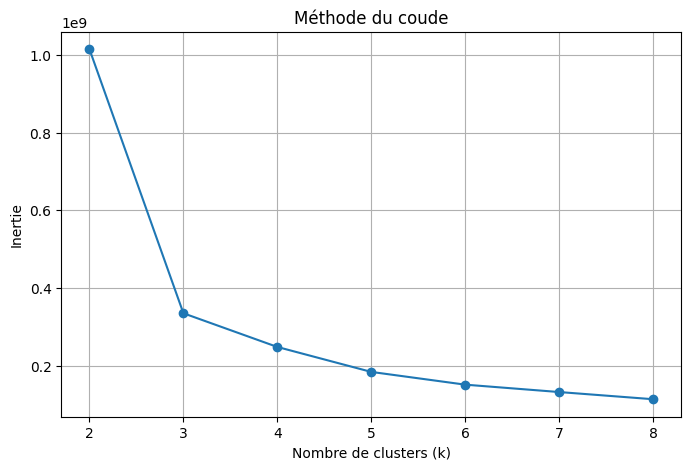

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(
    resultats["k"],
    resultats["inertie"],
    marker="o"
)
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.grid(True)
plt.show()

In [44]:
meilleur_k = resultats.loc[
    resultats["silhouette"].idxmax(),
    "k"
]

print("Meilleur k :", meilleur_k)

Meilleur k : 2


In [45]:
X_scaled = scaler.fit_transform(df)
kmeans = KMeans(
    n_clusters=meilleur_k,
    n_init=10,
    random_state=42
)

df["cluster"] = kmeans.fit_predict(X_scaled)

In [46]:
profil_clusters = (
    df.groupby("cluster")
      .mean()
      .round(2)
)

print(profil_clusters)

          price  minimum_nights  number_of_reviews  reviews_per_month  \
cluster                                                                 
0        127.22            2.06             236.85               4.41   
1        184.72           18.51              35.98               1.06   

         availability_365  number_of_reviews_ltm  \
cluster                                            
0                  229.11                  51.46   
1                  196.82                   8.45   

         calculated_host_listings_count  
cluster                                  
0                                  7.00  
1                                  8.27  


In [48]:
#cas limite
df_small = df.head(100)
resultats = choisir_k(df_small, range(2, 9))

k    Inertie        Silhouette
-----------------------------------
2    2879887.60     0.4391
3    2013400.96     0.3507
4    1539849.31     0.3665
5    1302119.48     0.3358
6    1121512.53     0.3365
7    995274.35      0.3274
8    885895.09      0.3257


In [61]:
#cas advesarial
nouvelle_annonce = {
    "price": 50000.0,
    "minimum_nights": 365,
    "number_of_reviews": 0,
    "availability_365": 365,
    "reviews_per_month":  4.41,
    "number_of_reviews_ltm": 8.45,
    "calculated_host_listings_count": 7.00
}
# transformer en DataFrame
add = pd.DataFrame([nouvelle_annonce])

# ajouter au df existant
df_adve = pd.concat([df, add], ignore_index=True)
print(df.loc[df["price"].idxmax()])

price                             50000.00
minimum_nights                        1.00
number_of_reviews                     1.00
reviews_per_month                     0.06
availability_365                    326.00
number_of_reviews_ltm                 0.00
calculated_host_listings_count       12.00
cluster                               1.00
Name: 10565, dtype: float64


In [62]:
df_adve = df.fillna(0)
resultats = choisir_k(df_adve, range(2, 9))

k    Inertie        Silhouette
-----------------------------------
2    1015336241.92  0.9945
3    334764343.94   0.9745
4    247902332.02   0.3426
5    183584676.01   0.3901
6    150736678.27   0.4046
7    131707224.02   0.3892
8    113198471.49   0.4024


In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

def vectoriser_textes(messages, vectorizer=None):
    """
    Transforme une liste de textes en matrice numérique.
    Retourne (X, vectorizer)
    """

    if vectorizer is None:
        vectorizer = TfidfVectorizer()
        X = vectorizer.fit_transform(messages)
    else:
        X = vectorizer.transform(messages)

    return X, vectorizer

In [66]:
from sklearn.metrics import classification_report

def evaluer_spam(modele, X_train, X_test, y_train, y_test):
    """
    Entraîne, prédit, affiche precision/recall/f1 (classe spam surtout)
    """

    # entraînement
    modele.fit(X_train, y_train)

    # prédiction
    y_pred = modele.predict(X_test)

    # rapport complet
    print(classification_report(y_test, y_pred))

In [67]:
import pandas as pd

df = pd.read_csv("SMSSpamCollection.txt", sep="\t", header=None, names=["label", "message"])

In [68]:
X = df["message"]
y = df["label"]

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train_vec, vectorizer = vectoriser_textes(X_train)
X_test_vec, _ = vectoriser_textes(X_test, vectorizer)

In [70]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
evaluer_spam(nb, X_train_vec, X_test_vec, y_train, y_test)

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.70      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115



In [71]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
evaluer_spam(lr, X_train_vec, X_test_vec, y_train, y_test)

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [73]:
import numpy as np

def tester_cas(model, vectorizer):

    # =========================
    # 1. HAPPY PATH
    # =========================
    happy_messages = [
        "WINNER!! You have won a free prize claim now",
        "Free entry in a cash prize competition call now",
        "URGENT! You are selected for a £1000 reward"
    ]

    X_happy = vectorizer.transform(happy_messages)
    pred_happy = model.predict(X_happy)

    print("\n===== HAPPY PATH =====")
    for msg, pred in zip(happy_messages, pred_happy):
        print(f"{msg} -> {pred}")


    # =========================
    # 2. EDGE CASE (message vide)
    # =========================
    edge_message = [""]

    X_edge = vectorizer.transform(edge_message)
    pred_edge = model.predict(X_edge)

    print("\n===== EDGE CASE (VIDE) =====")
    print(f"Message vide -> {pred_edge[0]}")


    # =========================
    # 3. ADVERSARIAL CASE
    # =========================
    adversarial_messages = [
        "salut, ton colis t attend, confirme ici",
        "hey how are you doing today",
        "ok on se voit demain à 18h"
    ]

    X_adv = vectorizer.transform(adversarial_messages)
    pred_adv = model.predict(X_adv)

    print("\n===== ADVERSARIAL CASE =====")
    for msg, pred in zip(adversarial_messages, pred_adv):
        print(f"{msg} -> {pred}")

In [74]:
tester_cas(nb, vectorizer)


===== HAPPY PATH =====
WINNER!! You have won a free prize claim now -> spam
Free entry in a cash prize competition call now -> spam
URGENT! You are selected for a £1000 reward -> spam

===== EDGE CASE (VIDE) =====
Message vide -> ham

===== ADVERSARIAL CASE =====
salut, ton colis t attend, confirme ici -> ham
hey how are you doing today -> ham
ok on se voit demain à 18h -> ham


In [75]:
tester_cas(lr, vectorizer)


===== HAPPY PATH =====
WINNER!! You have won a free prize claim now -> spam
Free entry in a cash prize competition call now -> spam
URGENT! You are selected for a £1000 reward -> ham

===== EDGE CASE (VIDE) =====
Message vide -> ham

===== ADVERSARIAL CASE =====
salut, ton colis t attend, confirme ici -> ham
hey how are you doing today -> ham
ok on se voit demain à 18h -> ham


In [79]:
import pandas as pd

def charger_sonar(url):
    """
    Charge le dataset sonar, sépare X et y,
    convertit les labels et affiche la répartition.
    """

    # lecture du dataset
    df = pd.read_csv(url, header=None)

    # séparation features / label
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    # conversion M/R -> 1/0
    y = y.map({"M": 1, "R": 0})

    # affichage répartition
    print("Répartition des classes :")
    print(y.value_counts())
    print("\nProportion :")
    print(y.value_counts(normalize=True))

    return X, y

In [80]:
X, y = charger_sonar("sonar.csv")


Répartition des classes :
60
1    111
0     97
Name: count, dtype: int64

Proportion :
60
1    0.533654
0    0.466346
Name: proportion, dtype: float64


In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [83]:
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("\n===== LOGISTIC REGRESSION =====")
print(classification_report(y_test, y_pred_lr))


===== LOGISTIC REGRESSION =====
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        20
           1       0.83      0.86      0.84        22

    accuracy                           0.83        42
   macro avg       0.83      0.83      0.83        42
weighted avg       0.83      0.83      0.83        42



In [85]:
from sklearn.svm import SVC
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf"))
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

print("\n===== SVM RBF =====")
print(classification_report(y_test, y_pred_svm))


===== SVM RBF =====
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        20
           1       0.88      1.00      0.94        22

    accuracy                           0.93        42
   macro avg       0.94      0.93      0.93        42
weighted avg       0.94      0.93      0.93        42



In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [87]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("\n===== LOGISTIC REGRESSION =====")
print(classification_report(y_test, y_pred_lr))


===== LOGISTIC REGRESSION =====
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        20
           1       0.83      0.86      0.84        22

    accuracy                           0.83        42
   macro avg       0.83      0.83      0.83        42
weighted avg       0.83      0.83      0.83        42



In [88]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf"))
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

print("\n===== SVM RBF =====")
print(classification_report(y_test, y_pred_svm))


===== SVM RBF =====
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        20
           1       0.88      1.00      0.94        22

    accuracy                           0.93        42
   macro avg       0.94      0.93      0.93        42
weighted avg       0.94      0.93      0.93        42



In [90]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n===== RANDOM FOREST =====")
print(classification_report(y_test, y_pred_rf))


===== RANDOM FOREST =====
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        20
           1       0.79      0.86      0.83        22

    accuracy                           0.81        42
   macro avg       0.81      0.81      0.81        42
weighted avg       0.81      0.81      0.81        42



In [91]:
def test_normal(lr_pipeline, svm_pipeline, rf_model, X_test, y_test):

    print("\n===== CAS NORMAL =====")

    # Logistic Regression
    y_lr = lr_pipeline.predict(X_test)
    print("\n--- Logistic Regression ---")
    print(classification_report(y_test, y_lr))

    # SVM
    y_svm = svm_pipeline.predict(X_test)
    print("\n--- SVM RBF ---")
    print(classification_report(y_test, y_svm))

    # Random Forest
    y_rf = rf_model.predict(X_test)
    print("\n--- Random Forest ---")
    print(classification_report(y_test, y_rf))

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# modèles SANS scaler
lr_no_scaling = LogisticRegression(max_iter=1000)
svm_no_scaling = SVC(kernel="rbf")

In [93]:
lr_no_scaling.fit(X_train, y_train)
svm_no_scaling.fit(X_train, y_train)

y_lr_ns = lr_no_scaling.predict(X_test)
y_svm_ns = svm_no_scaling.predict(X_test)
y_rf = rf_model.predict(X_test)  # RF inchangé

In [94]:
print("\n===== CAS LIMITE : SANS STANDARDISATION =====")

print("\n--- Logistic Regression (sans scaling) ---")
print(classification_report(y_test, y_lr_ns))

print("\n--- SVM RBF (sans scaling) ---")
print(classification_report(y_test, y_svm_ns))

print("\n--- Random Forest ---")
print(classification_report(y_test, y_rf))


===== CAS LIMITE : SANS STANDARDISATION =====

--- Logistic Regression (sans scaling) ---
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        20
           1       0.79      0.86      0.83        22

    accuracy                           0.81        42
   macro avg       0.81      0.81      0.81        42
weighted avg       0.81      0.81      0.81        42


--- SVM RBF (sans scaling) ---
              precision    recall  f1-score   support

           0       0.93      0.70      0.80        20
           1       0.78      0.95      0.86        22

    accuracy                           0.83        42
   macro avg       0.86      0.83      0.83        42
weighted avg       0.85      0.83      0.83        42


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        20
           1       0.79      0.86      0.83        22

    accuracy                        

In [95]:
import time
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

def fight_des_ia(X_train, X_test, y_train, y_test, metrique):
    """
    Entraîne plusieurs modèles sur le même split,
    retourne un leaderboard trié (score + temps).
    """

    competiteurs = {
        "LogisticRegression": LogisticRegression(max_iter=5000),
        "DecisionTree": DecisionTreeClassifier(random_state=42),
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
        "GradientBoosting": GradientBoostingClassifier(random_state=42),
        "SVC_rbf": SVC(kernel="rbf"),
        "NaiveBayes": GaussianNB()
    }

    resultats = []

    for nom, modele in competiteurs.items():

        start = time.perf_counter()

        # entraînement
        modele.fit(X_train, y_train)

        # prédiction
        y_pred = modele.predict(X_test)

        end = time.perf_counter()

        # métrique personnalisée
        score = metrique(y_test, y_pred)

        resultats.append({
            "algo": nom,
            "score": score,
            "temps": end - start
        })

    # tri par score décroissant
    leaderboard = pd.DataFrame(resultats)
    leaderboard = leaderboard.sort_values(by="score", ascending=False)

    print("\n=== LEADERBOARD ===")
    print(leaderboard.to_string(index=False))

    return leaderboard

In [96]:
from sklearn.metrics import f1_score

def f1_mines(y_true, y_pred):
    return f1_score(y_true, y_pred)

In [97]:
leaderboard = fight_des_ia(
    X_train,
    X_test,
    y_train,
    y_test,
    metrique=f1_mines
)


=== LEADERBOARD ===
              algo    score    temps
  GradientBoosting 0.863636 1.530469
      DecisionTree 0.857143 0.020263
           SVC_rbf 0.857143 0.020128
      RandomForest 0.844444 1.408015
LogisticRegression 0.826087 0.023750
        NaiveBayes 0.731707 0.012828
